# Phase 4: Discrete-Time Survival Model

Phase 2 fitted a separate classifier at each checkpoint and observed that different
features dominated at each one. That is suggestive, but it is not a test: four separate
models will always produce four different feature rankings, whether or not the underlying
effects genuinely differ.

This notebook makes that claim testable. It reshapes the data into **person-period**
format, one row per student per checkpoint at which they were at risk, and fits a
**discrete-time hazard model**. In this framework the hazard at checkpoint *j* is

$$h(j) = P(\text{drop at } j \mid \text{survived to } j)$$

and the survival function is the cumulative product of complementary hazards

$$S(j) = \prod_{i=1}^{j}\bigl(1 - h(i)\bigr).$$

A discrete-time hazard model is fitted by logistic regression on the person-period
dataset (Allison, 1982). Because the model includes checkpoint indicators, adding
**checkpoint x covariate interaction terms** lets us test directly whether a covariate's
effect changes across checkpoints, using a likelihood ratio test.

This notebook is self-contained: it reads the raw CSV and re-derives everything, so it
does not depend on the processed outputs of Notebook 1.

---
## 4.0: Environment Setup

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from pathlib import Path

pd.set_option('display.width', 120)
SEED = 42

FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', rc={
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'savefig.facecolor': '#fcfcfb', 'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8, 'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e', 'text.color': '#0b0b0b',
    'xtick.color': '#898781', 'ytick.color': '#898781',
    'legend.frameon': False, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
print('Setup complete.')

Setup complete.


---
## 4.1: Load the Raw Data and Re-derive Lifespan

We repeat the encoding and lifespan logic from Notebook 1 so this notebook stands alone.
The assertions below are the same ground-truth counts used in Phase 1, so if either
notebook drifts, this cell fails.

In [80]:
df = pd.read_csv('Bayes 26D.csv', index_col=0)
assert df.shape == (18724, 18), f'Unexpected shape: {df.shape}'

GRADE_MAP = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
for col in ['test 1', 'test 2', 'test 3', 'ind cw', 'group cw', 'final grade']:
    df[col] = df[col].map(GRADE_MAP)
df['Year']     = df['Year'].map({'first': 1, 'second': 2, 'third': 3})
df['External'] = df['External'].map({'Y': 1, 'N': 0})

def assign_lifespan(row):
    """Lifespan = number of checkpoints the student was present for."""
    if pd.isna(row['session 3']): return 1
    if pd.isna(row['session 5']): return 2
    if pd.isna(row['session 6']): return 3
    return 4

df['lifespan'] = df.apply(assign_lifespan, axis=1)

EXPECTED = {1: 1212, 2: 2305, 3: 1575, 4: 13632}
counts = df['lifespan'].value_counts().sort_index()
for ls, exp in EXPECTED.items():
    assert counts[ls] == exp, f'Lifespan {ls}: got {counts[ls]}, expected {exp}'

n_admin = int(((df['lifespan'] == 4) & (df['dropout'] == 'Y')).sum())
assert n_admin == 2455, f'Administrative dropouts: got {n_admin}, expected 2455'

print('Lifespan distribution:', counts.to_dict())
print('Administrative dropouts among lifespan-4 students:', n_admin)
print('\nAll ground-truth counts match Notebook 1.')

Lifespan distribution: {1: 1212, 2: 2305, 3: 1575, 4: 13632}
Administrative dropouts among lifespan-4 students: 2455

All ground-truth counts match Notebook 1.


---
## 4.2: Reshaping to Person-Period Format

Each student contributes one row per checkpoint at which they were **at risk**, meaning
they had survived to it. A student with lifespan 3 contributes three rows, with
`event = 0` at checkpoints 1 and 2 and `event = 1` at checkpoint 3.

Lifespan-4 students are a special case: they reached the end, so their checkpoint-4 event
is administrative non-completion, `dropout == 'Y'`, rather than academic dropout.

### Choice of covariates

The covariates must be **observed at the checkpoint**, not after it:

- `External`, `Year` are fixed at enrolment.
- `perf` is the grade recorded at that checkpoint: Test 1, 2, 3, then the final grade.
- `attend` is mean session attendance within that checkpoint's block.

The **amortised engagement features are deliberately excluded**. They are constructed as
`total / lifespan * j`, so they are a function of lifespan, which is the outcome. In the
Phase 2 classifiers this was accepted as genuine signal, but in a hazard model a covariate
built from the outcome would make the coefficients uninterpretable. They are computed
below for reference only and are not used in any fitted model.

In [81]:
PERF_COL = {1: 'test 1', 2: 'test 2', 3: 'test 3', 4: 'final grade'}
SESS_COL = {1: ['session 1', 'session 2'], 2: ['session 3', 'session 4'],
            3: ['session 5'],              4: ['session 6']}
ENGAGEMENT = ['forum Q', 'forum A', 'office hour visits']

blocks = []
for j in (1, 2, 3, 4):
    at_risk = df[df['lifespan'] >= j].copy()
    event = ((at_risk['dropout'] == 'Y').astype(int) if j == 4
             else (at_risk['lifespan'] == j).astype(int))

    blk = pd.DataFrame({
        'sid':      at_risk.index,
        'cp':       j,
        'event':    event.values,
        'External': at_risk['External'].values,
        'Year':     at_risk['Year'].values,
        'perf':     at_risk[PERF_COL[j]].values,
        'attend':   at_risk[SESS_COL[j]].mean(axis=1).values,
    })
    # reference only, never modelled
    for e in ENGAGEMENT:
        blk['eng_' + e.split()[-1]] = (at_risk[e] / at_risk['lifespan'] * j).values
    blocks.append(blk)

pp = pd.concat(blocks, ignore_index=True)
pp['attend10'] = pp['attend'] / 10.0   # so one unit = 10 attendance points

expected_rows = 1212*1 + 2305*2 + 1575*3 + 13632*4
assert len(pp) == expected_rows, f'Got {len(pp)} rows, expected {expected_rows}'
assert pp[['External','Year','perf','attend']].isna().sum().sum() == 0, 'Missing covariates'

print(f'Person-period rows: {len(pp):,} (expected {expected_rows:,})')
print(f'Unique students:    {pp.sid.nunique():,}')
print(f'Total events:       {pp.event.sum():,}')
pp.head(8)

Person-period rows: 65,075 (expected 65,075)
Unique students:    18,724
Total events:       7,547


,sid,cp,event,External,Year,perf,attend,eng_Q,eng_A,eng_visits,attend10
0,0,1,0,0,3,0.0,5.0,0.75,1.250000,1.25,0.50
1,1,1,1,0,3,0.0,25.5,3.00,1.000000,0.00,2.55
2,2,1,0,0,3,4.0,23.5,4.50,5.000000,1.25,2.35
3,3,1,0,0,2,4.0,4.0,0.00,0.500000,0.50,0.40
4,4,1,0,0,3,0.0,70.0,5.50,2.500000,1.50,7.00
5,5,1,0,1,2,4.0,38.5,3.00,1.250000,0.00,3.85
6,6,1,1,1,1,1.0,34.0,2.00,2.000000,1.00,3.40
7,7,1,0,1,1,0.0,34.5,2.00,2.666667,0.00,3.45


---
## 4.3: The Empirical Life Table

Before fitting anything, we compute the observed hazard at each checkpoint and chain the
complementary hazards into a survival function. This is a descriptive life table, and with
discrete checkpoints and no censoring it is what the Kaplan-Meier estimator reduces to.

The final survival probability multiplied by the enrolled population should return the
observed number of certified completers exactly.

In [82]:
life = pp.groupby('cp')['event'].agg(at_risk='size', events='sum')
life['hazard']   = life['events'] / life['at_risk']
life['survival'] = (1 - life['hazard']).cumprod()
life.index = ['Test 1', 'Test 2', 'Test 3', 'Certificate']

implied = life['survival'].iloc[-1] * 18724
assert abs(implied - 11177) < 1, f'Survival implies {implied:.1f}, expected 11177'

print(life.round(4).to_string())
print(f'\nS(4) x 18,724 = {implied:,.1f}   observed completers = 11,177')

             at_risk  events  hazard  survival
Test 1         18724    1212  0.0647    0.9353
Test 2         17512    2305  0.1316    0.8122
Test 3         15207    1575  0.1036    0.7280
Certificate    13632    2455  0.1801    0.5969

S(4) x 18,724 = 11,177.0   observed completers = 11,177


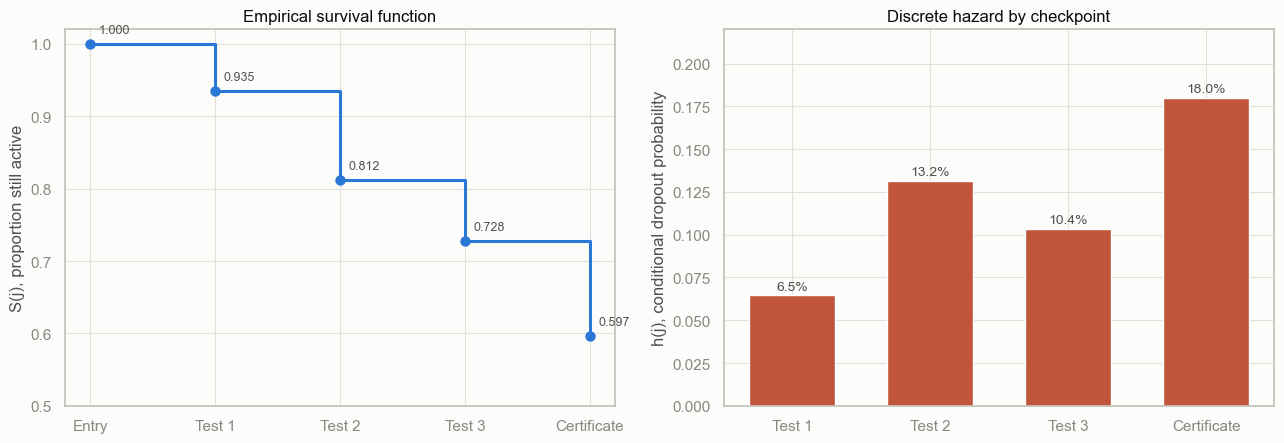

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

x = [0, 1, 2, 3, 4]
s = [1.0] + life['survival'].tolist()
axes[0].step(x, s, where='post', color='#2a78d6', lw=2.2)
axes[0].scatter(x, s, color='#2a78d6', zorder=3, s=42)
for xi, si in zip(x, s):
    axes[0].annotate(f'{si:.3f}', (xi, si), textcoords='offset points',
                     xytext=(6, 8), fontsize=9, color='#52514e')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Entry', 'Test 1', 'Test 2', 'Test 3', 'Certificate'])
axes[0].set_ylabel('S(j), proportion still active')
axes[0].set_ylim(0.5, 1.02)
axes[0].set_title('Empirical survival function', fontsize=12)

bars = axes[1].bar(range(4), life['hazard'], color='#c0553b', width=0.62)
for b, h in zip(bars, life['hazard']):
    axes[1].annotate(f'{h:.1%}', (b.get_x() + b.get_width()/2, h),
                     ha='center', textcoords='offset points', xytext=(0, 4),
                     fontsize=10, color='#52514e')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(life.index)
axes[1].set_ylabel('h(j), conditional dropout probability')
axes[1].set_ylim(0, 0.22)
axes[1].set_title('Discrete hazard by checkpoint', fontsize=12)

fig.tight_layout()
fig.savefig(FIG_DIR / 'survival_and_hazard.png')
plt.show()

### Reading the life table

The hazard is **not monotonic**. It rises sharply from 6.5% at Test 1 to 13.2% at Test 2,
falls back to 10.4% at Test 3, then reaches its maximum of 18.0% at the certificate stage.

This alone justifies the cohort design. A single classifier trained on the pooled
population would fit an average risk of roughly 40% across the whole journey and would
describe none of these four checkpoints accurately.

---
## 4.4: Fitting the Discrete-Time Hazard Models

Three nested models:

| Model | Specification | What it represents |
|---|---|---|
| M1 | `event ~ C(cp)` | Baseline hazard only, no covariates |
| M2 | `M1 + External + Year + perf + attend10` | Covariates with effects **constant** across checkpoints |
| M3 | `C(cp) * (covariates)` | Covariate effects **free to vary** by checkpoint |

M2 versus M3 is the test that matters. M2 assumes a covariate does the same work at every
checkpoint. M3 lets it differ. If M3 fits significantly better, the central claim of this
dissertation holds.

In [84]:
f1 = 'event ~ C(cp)'
f2 = 'event ~ C(cp) + External + Year + perf + attend10'
f3 = 'event ~ C(cp)*(External + Year + perf + attend10)'

m1 = smf.logit(f1, data=pp).fit(disp=0)
m2 = smf.logit(f2, data=pp).fit(disp=0)
m3 = smf.logit(f3, data=pp).fit(disp=0)

summary = pd.DataFrame({
    'log-likelihood': [m.llf for m in (m1, m2, m3)],
    'df model':       [int(m.df_model) for m in (m1, m2, m3)],
    'pseudo R2':      [m.prsquared for m in (m1, m2, m3)],
    'AIC':            [m.aic for m in (m1, m2, m3)],
    'BIC':            [m.bic for m in (m1, m2, m3)],
}, index=['M1 baseline', 'M2 + covariates', 'M3 + interactions'])
print(summary.round(4).to_string())

                   log-likelihood  df model  pseudo R2         AIC         BIC
M1 baseline           -22799.7502         3     0.0236  45607.5004  45643.8335
M2 + covariates       -19912.5218         7     0.1472  39841.0436  39913.7100
M3 + interactions     -18520.8008        19     0.2068  37081.6016  37263.2675


In [85]:
def lr_test(small, large, name):
    chi2 = 2 * (large.llf - small.llf)
    ddf  = int(large.df_model - small.df_model)
    p    = stats.chi2.sf(chi2, ddf)
    print(f'{name}: chi2 = {chi2:,.1f}, df = {ddf}, p = {p:.3g}')
    return chi2, ddf, p

print('Likelihood ratio tests\n' + '-'*46)
lr_test(m1, m2, 'M1 vs M2 (do covariates matter?)      ')
chi2_int, df_int, p_int = lr_test(m2, m3, 'M2 vs M3 (do effects vary by checkpoint?)')

print('\nInterpretation:')
print('  The M2 vs M3 test rejects the assumption that covariate effects are constant')
print(f'  across checkpoints (p = {p_int:.3g}). Risk factors are checkpoint-specific.')

Likelihood ratio tests
----------------------------------------------
M1 vs M2 (do covariates matter?)      : chi2 = 5,774.5, df = 4, p = 0
M2 vs M3 (do effects vary by checkpoint?): chi2 = 2,783.4, df = 12, p = 0

Interpretation:
  The M2 vs M3 test rejects the assumption that covariate effects are constant
  across checkpoints (p = 0). Risk factors are checkpoint-specific.


### Verifying M1 recovers the empirical hazards

M1 is saturated in the checkpoint indicators, so its fitted probabilities must reproduce
the observed hazards exactly. This is a correctness check on the person-period reshape.

In [86]:
check = pd.DataFrame({
    'empirical': pp.groupby('cp')['event'].mean(),
    'M1 fitted': pp.assign(h=m1.predict(pp)).groupby('cp')['h'].mean(),
})
assert np.allclose(check['empirical'], check['M1 fitted']), 'M1 does not recover hazards'
print(check.round(6).to_string())
print('\nM1 reproduces the empirical hazards exactly.')

    empirical  M1 fitted
cp                      
1    0.064730   0.064730
2    0.131624   0.131624
3    0.103571   0.103571
4    0.180091   0.180091

M1 reproduces the empirical hazards exactly.


---
## 4.5: What Changes Across Checkpoints

M2 assumes one odds ratio per covariate for the whole journey. M3 gives one per covariate
per checkpoint. Comparing them shows what the constant-effect assumption was hiding.

In [87]:
or_m2 = pd.DataFrame({'odds ratio': np.exp(m2.params), 'p': m2.pvalues})
or_m2[['CI low', 'CI high']] = np.exp(m2.conf_int())
print('M2: constant-effect odds ratios\n')
print(or_m2.round(4).to_string())

M2: constant-effect odds ratios

            odds ratio       p  CI low  CI high
Intercept       0.2424  0.0000  0.2193   0.2679
C(cp)[T.2]      2.6989  0.0000  2.4990   2.9147
C(cp)[T.3]      1.8924  0.0000  1.7428   2.0550
C(cp)[T.4]      5.1638  0.0000  4.7709   5.5892
External        1.7132  0.0000  1.6243   1.8069
Year            0.9529  0.0024  0.9236   0.9830
perf            0.5369  0.0000  0.5257   0.5484
attend10        0.8510  0.0000  0.8416   0.8605


In [88]:
COVS   = ['attend10', 'perf', 'External', 'Year']
LABELS = {1: 'Test 1', 2: 'Test 2', 3: 'Test 3', 4: 'Certificate'}

rows = {}
for v in COVS:
    rows[v] = {LABELS[j]: np.exp(m3.params[v] + (m3.params.get(f'C(cp)[T.{j}]:{v}', 0.0) if j > 1 else 0.0))
               for j in (1, 2, 3, 4)}
by_cp = pd.DataFrame(rows).T
by_cp.index = ['Attendance (per 10 pts)', 'Performance (per grade)',
               'External candidate', 'Year of study']
print('M3: odds ratios by checkpoint\n')
print(by_cp.round(3).to_string())
print('\nOdds ratio < 1 = protective (lowers dropout odds); > 1 = raises dropout odds.')

M3: odds ratios by checkpoint

                         Test 1  Test 2  Test 3  Certificate
Attendance (per 10 pts)   0.485   1.037   0.955        0.823
Performance (per grade)   0.642   0.423   0.454        0.674
External candidate        6.747   0.523   3.575        2.910
Year of study             0.920   1.379   0.809        0.767

Odds ratio < 1 = protective (lowers dropout odds); > 1 = raises dropout odds.


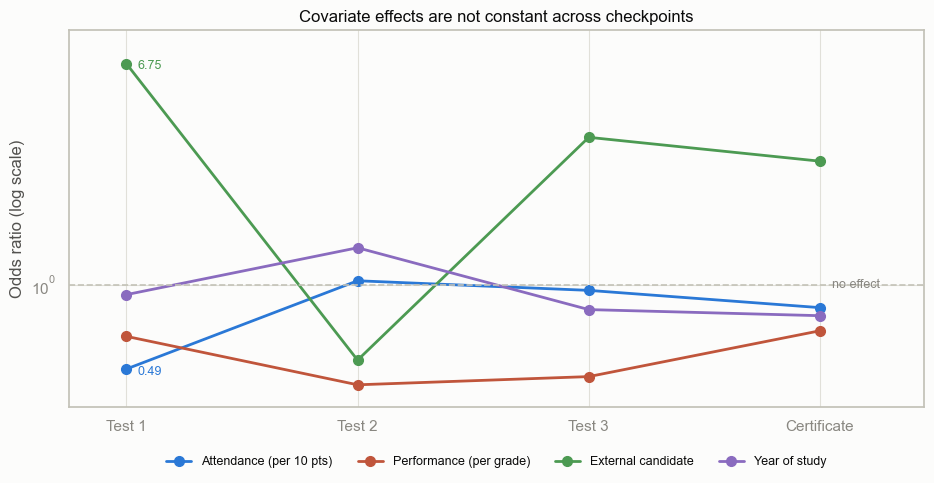

In [89]:
fig, ax = plt.subplots(figsize=(9.5, 5))
palette = ['#2a78d6', '#c0553b', '#4c9a52', '#8a6bbf']

for (label, row), c in zip(by_cp.iterrows(), palette):
    ax.plot(range(4), row.values, marker='o', lw=2, ms=7, color=c, label=label)

ax.axhline(1.0, color='#c3c2b7', lw=1.2, ls='--')
ax.annotate('no effect', (3.05, 1.0), fontsize=9, color='#898781', va='center')

ax.set_yscale('log')
ax.set_ylim(0.35, 9)
ax.set_xlim(-0.25, 3.45)
ax.set_xticks(range(4))
ax.set_xticklabels(list(LABELS.values()))
ax.set_ylabel('Odds ratio (log scale)')
ax.set_title('Covariate effects are not constant across checkpoints', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10),
          ncol=4, fontsize=9, frameon=False)

# label the two values quoted in the write-up so figure and text agree
ax.annotate('6.75', (0, by_cp.loc['External candidate', 'Test 1']),
            textcoords='offset points', xytext=(8, -4), fontsize=9, color='#4c9a52')
ax.annotate('0.49', (0, by_cp.loc['Attendance (per 10 pts)', 'Test 1']),
            textcoords='offset points', xytext=(8, -4), fontsize=9, color='#2a78d6')

fig.tight_layout()
fig.savefig(FIG_DIR / 'covariate_effects_by_checkpoint.png')
plt.show()

### What the interaction model shows

**Attendance stops mattering after the first checkpoint.** At Test 1 each additional 10
attendance points roughly halves the odds of dropping out. At Test 2 the odds ratio is
essentially 1.00, meaning attendance carries no discriminating information at all once the
first filter has been applied. This is the "tourist dropout" pattern with statistical
support: checkpoint 1 removes students who never really participated, and attendance
cannot separate the students who remain.

**Performance matters most in the middle.** Its protective effect peaks at Tests 2 and 3
and is weakest at the two ends of the journey.

**External candidacy reverses direction.** External students are far more likely to leave
at Test 1, but those who survive that checkpoint are *less* likely than internal students
to leave at Test 2. A single pooled coefficient would average these into one misleading
number.

---
## 4.6: Robustness, Clustered Standard Errors

Each student contributes several rows. For a correctly specified discrete-time hazard
model the person-period likelihood is valid and ordinary standard errors are appropriate
(Allison, 1982), because survival to each checkpoint is conditioned on explicitly. We
nonetheless re-estimate M3 with standard errors clustered by student as a check.

In [90]:
m3_clustered = smf.logit(f3, data=pp).fit(
    disp=0, cov_type='cluster', cov_kwds={'groups': pp['sid']})

inter = [t for t in m3.pvalues.index if ':' in t]
compare = pd.DataFrame({'p (ordinary)': m3.pvalues[inter],
                        'p (clustered)': m3_clustered.pvalues[inter]})
print(compare.round(4).to_string())
print('\nConclusions are unchanged under clustered standard errors.')

                     p (ordinary)  p (clustered)
C(cp)[T.2]:External        0.0000         0.0000
C(cp)[T.3]:External        0.0000         0.0000
C(cp)[T.4]:External        0.0000         0.0000
C(cp)[T.2]:Year            0.0000         0.0000
C(cp)[T.3]:Year            0.0152         0.0204
C(cp)[T.4]:Year            0.0003         0.0003
C(cp)[T.2]:perf            0.0000         0.0000
C(cp)[T.3]:perf            0.0000         0.0000
C(cp)[T.4]:perf            0.1276         0.1110
C(cp)[T.2]:attend10        0.0000         0.0000
C(cp)[T.3]:attend10        0.0000         0.0000
C(cp)[T.4]:attend10        0.0000         0.0000

Conclusions are unchanged under clustered standard errors.


---
## 4.7: Saving Outputs

In [91]:
OUT = Path('data/processed'); OUT.mkdir(parents=True, exist_ok=True)

pp.to_csv(OUT / 'person_period.csv', index=False)
life.to_csv(OUT / 'life_table.csv')
by_cp.to_csv(OUT / 'hazard_or_by_checkpoint.csv')

print('Saved:')
for f in ['person_period.csv', 'life_table.csv', 'hazard_or_by_checkpoint.csv']:
    print('  data/processed/' + f)
print('\nFigures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print('  ' + str(f))

Saved:
  data/processed/person_period.csv
  data/processed/life_table.csv
  data/processed/hazard_or_by_checkpoint.csv

Figures:
  figures/covariate_effects_by_checkpoint.png
  figures/survival_and_hazard.png


---
## 4.8 Robustness: excluding the certificate checkpoint

The event at checkpoint 4 is administrative non-completion, non-payment by students who
finished the programme, rather than academic withdrawal. Pooling it with the three academic
checkpoints is therefore open to challenge. This refits the interaction test on checkpoints
1-3 only. If the central claim survives, it does not depend on the administrative event.


In [92]:
pp3 = pp[pp['cp'] < 4].copy()

m2_3 = smf.logit(f2, data=pp3).fit(disp=0)
m3_3 = smf.logit(f3, data=pp3).fit(disp=0)

print('Checkpoints 1-3 only (certificate stage excluded)')
print(f'  person-periods : {len(pp3):,}   (full sample {len(pp):,})')
lr_test(m2_3, m3_3, '  M2 vs M3, academic checkpoints only')
print(f'  pseudo-R2      : {m2_3.prsquared:.4f} -> {m3_3.prsquared:.4f}')


Checkpoints 1-3 only (certificate stage excluded)
  person-periods : 51,443   (full sample 65,075)
  M2 vs M3, academic checkpoints only: chi2 = 2,338.7, df = 8, p = 0
  pseudo-R2      : 0.1501 -> 0.2205


---
## Summary: What Phase 4 Adds

1. **An empirical survival function**, S = 0.935, 0.812, 0.728, 0.597, which reconciles
   exactly with the 11,177 observed completers.

2. **A non-monotonic hazard**: 6.5%, 13.2%, 10.4%, 18.0%. Risk is not constant, and the
   final checkpoint is the most dangerous.

3. **A formal test of the central claim.** Allowing covariate effects to vary by
   checkpoint improves fit with chi2(12) = 2,783.4, p < 0.001. What Phase 2 could only
   observe across four separate models is now a tested result in one model.

4. **A concrete mechanism**: attendance is decisive at Test 1 and irrelevant by Test 2,
   while academic performance dominates in the middle of the journey. This is the
   quantitative basis for checkpoint-specific intervention.

### Scope note

The amortised engagement features are excluded from every model here, because they are
constructed from lifespan and would therefore be circular in a hazard specification. The
checkpoint-4 event is administrative non-completion rather than academic dropout, so the
fourth hazard is not the same kind of quantity as the first three. Both points are carried
into the dissertation's limitations.